# Bussines Question

In [11]:
# =========================================================
# IMPORT LIBRARY
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [12]:
# Load dataset
df = pd.read_csv("dataset_with_features.csv")

In [13]:
df.head()

,resume_text,job_role,education,category,education_requirement,soft_skills_user,required_soft_skills,hard_skills_user,required_hard_skills_user,matched_skills,skill_gap,match_score
0,education: bachelor's in civil engineering exp...,geotechnical engineer,bachelor's in civil engineering,engineering,bachelor's in civil engineering,"['critical thinking', 'responsibility', 'profe...","['analysis', 'critical thinking', 'precision']","['technical drawing', 'structural analysis', '...","['structural analysis', 'building codes', 'tec...","['building codes', 'technical drawing', 'criti...","['analysis', 'precision']",0.73
1,education: bachelor's in marketing experience:...,email marketing specialist,bachelor's in marketing,economy,bachelor's in marketing,"['attention to detail', 'communication', 'crea...","['communication', 'creativity', 'attention to ...","['copywriting', 'crm', 'financial analysis', '...","['copywriting', 'crm', 'campaign management']","['crm', 'attention to detail', 'copywriting', ...",['campaign management'],0.87
2,education: bachelor's in robotics engineering ...,robotics engineer,bachelor's in robotics engineering,engineering,bachelor's in robotics engineering,"['problem solving', 'strategic thinking', 'qui...","['creativity', 'problem solving', 'strategic t...","['microcontrollers', 'embedded systems', 'elec...","['embedded systems', 'microcontrollers', 'matl...","['embedded systems', 'microcontrollers', 'stra...","['creativity', 'matlab']",0.73
3,education: bachelor's in business experience: ...,sales manager,bachelor's in business,economy,bachelor's in business,['business acumen'],"['decision making', 'communication', 'business...",['crm'],['crm'],"['crm', 'business acumen']","['decision making', 'communication']",0.60
4,education: bachelor's in multimedia experience...,fashion designer,bachelor's in multimedia,creative_design,bachelor's in fashion design|creative design c...,"['strategic planning', 'critical thinking', 'p...","['budget control', 'teamwork', 'business acumen']","['rendering', 'texturing']","['rendering', 'adobe creative suite']","['teamwork', 'budget control', 'rendering']","['business acumen', 'adobe creative suite']",0.48


In [14]:
# =========================================================
# FUNCTION MEMBERSIHKAN SKILL
# =========================================================

def split_skills(skill_text):

    if pd.isna(skill_text):
        return []

    # Menghapus simbol list
    skill_text = str(skill_text).replace("[", "")
    skill_text = skill_text.replace("]", "")
    skill_text = skill_text.replace("'", "")

    # Split skill
    skills = skill_text.split(",")

    # Membersihkan spasi
    return [
        skill.strip().lower()
        for skill in skills
        if skill.strip() != ""
    ]



TOP HARD SKILL PENGGUNA
             Hard Skill  Jumlah
0                python    1006
1                 excel     913
2                   cad     896
3                   sql     820
4        process design     728
5        legal research     724
6                matlab     699
7              rest api     688
8  adobe creative suite     676
9        graphic design     675


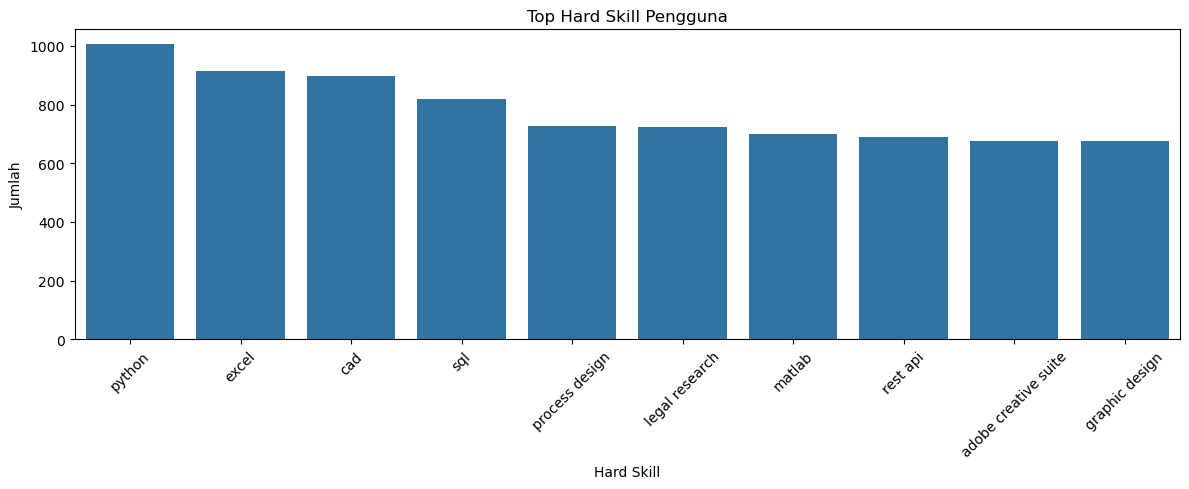

In [15]:
# =========================================================
# PERTANYAAN 1
# Apa hard skill yang paling sering dimiliki pengguna?
# =========================================================

hard_skill_counter = Counter()

for skills in df['hard_skills_user']:
    hard_skill_counter.update(split_skills(skills))

top_hard_skills = pd.DataFrame(
    hard_skill_counter.most_common(10),
    columns=['Hard Skill', 'Jumlah']
)

print("\n===================================")
print("TOP HARD SKILL PENGGUNA")
print("===================================")
print(top_hard_skills)

plt.figure(figsize=(12,5))

sns.barplot(
    data=top_hard_skills,
    x='Hard Skill',
    y='Jumlah'
)

plt.title("Top Hard Skill Pengguna")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



TOP SOFT SKILL PENGGUNA
            Soft Skill  Jumlah
0      problem solving    1859
1        communication    1789
2    critical thinking    1578
3             analysis    1529
4        collaboration    1390
5         adaptability    1382
6             teamwork    1355
7  attention to detail    1347
8            precision    1314
9             planning    1295


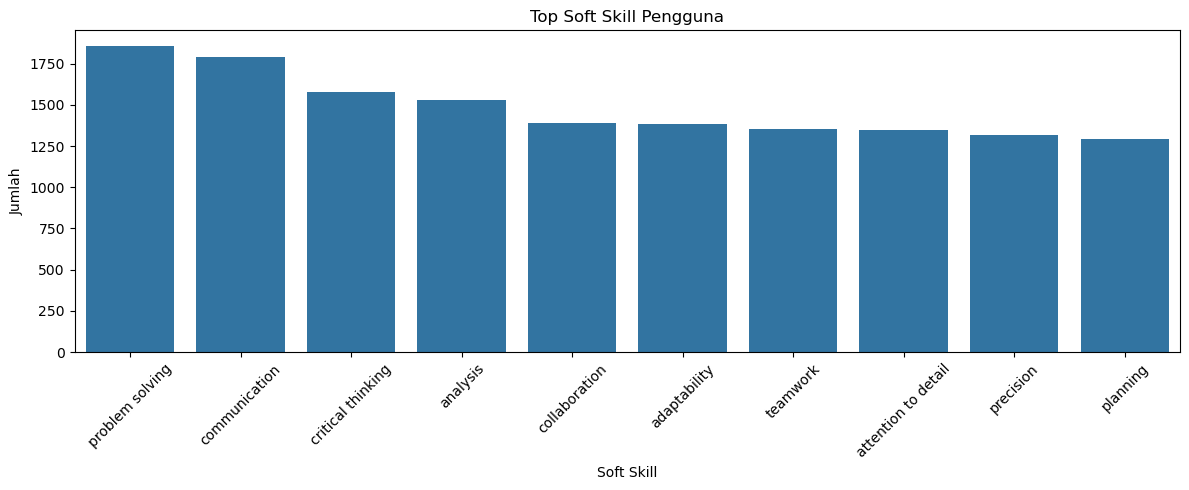

In [16]:
# =========================================================
# PERTANYAAN 2
# Apa soft skill yang paling sering muncul pada CV pengguna?
# =========================================================

soft_skill_counter = Counter()

for skills in df['soft_skills_user']:
    soft_skill_counter.update(split_skills(skills))

top_soft_skills = pd.DataFrame(
    soft_skill_counter.most_common(10),
    columns=['Soft Skill', 'Jumlah']
)

print("\n===================================")
print("TOP SOFT SKILL PENGGUNA")
print("===================================")
print(top_soft_skills)

plt.figure(figsize=(12,5))

sns.barplot(
    data=top_soft_skills,
    x='Soft Skill',
    y='Jumlah'
)

plt.title("Top Soft Skill Pengguna")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





TOP REQUIRED HARD SKILL
    Required Hard Skill  Jumlah
0                 excel     905
1        graphic design     822
2  adobe creative suite     804
3                   sql     779
4                   cad     754
5                matlab     637
6        legal research     635
7        process design     628
8                python     606
9      policy knowledge     583


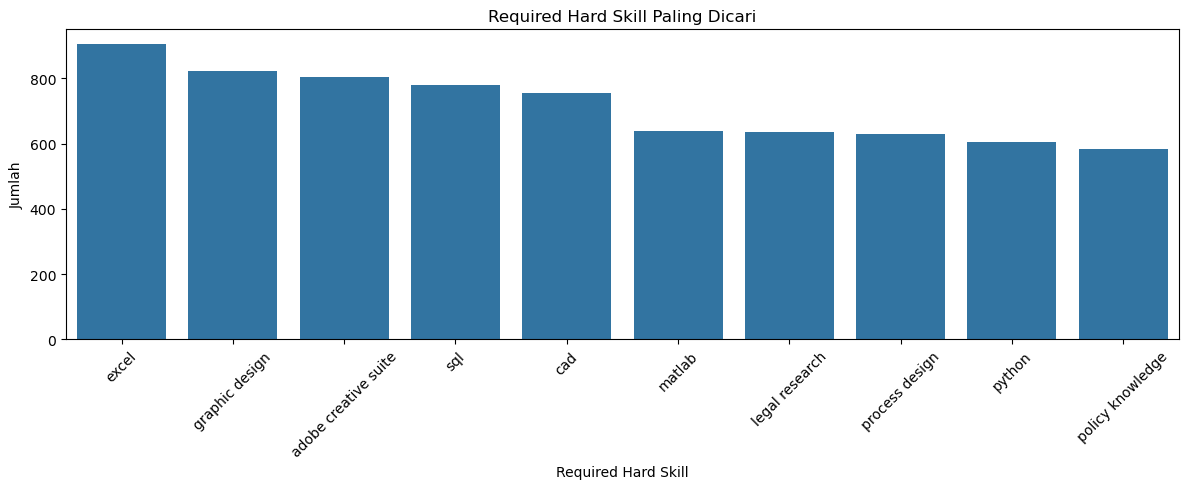

In [17]:
# =========================================================
# PERTANYAAN 3
# Apa required hard skill paling populer pada lowongan pekerjaan?
# =========================================================

required_hard_counter = Counter()

for skills in df['required_hard_skills_user']:
    required_hard_counter.update(split_skills(skills))

top_required_hard = pd.DataFrame(
    required_hard_counter.most_common(10),
    columns=['Required Hard Skill', 'Jumlah']
)

print("\n===================================")
print("TOP REQUIRED HARD SKILL")
print("===================================")
print(top_required_hard)

plt.figure(figsize=(12,5))

sns.barplot(
    data=top_required_hard,
    x='Required Hard Skill',
    y='Jumlah'
)

plt.title("Required Hard Skill Paling Dicari")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





TOP REQUIRED SOFT SKILL
   Required Soft Skill  Jumlah
0      problem solving    2017
1        communication    1986
2    critical thinking    1621
3             analysis    1616
4  attention to detail    1329
5         adaptability    1310
6        collaboration    1301
7             teamwork    1294
8            precision    1282
9             planning    1225


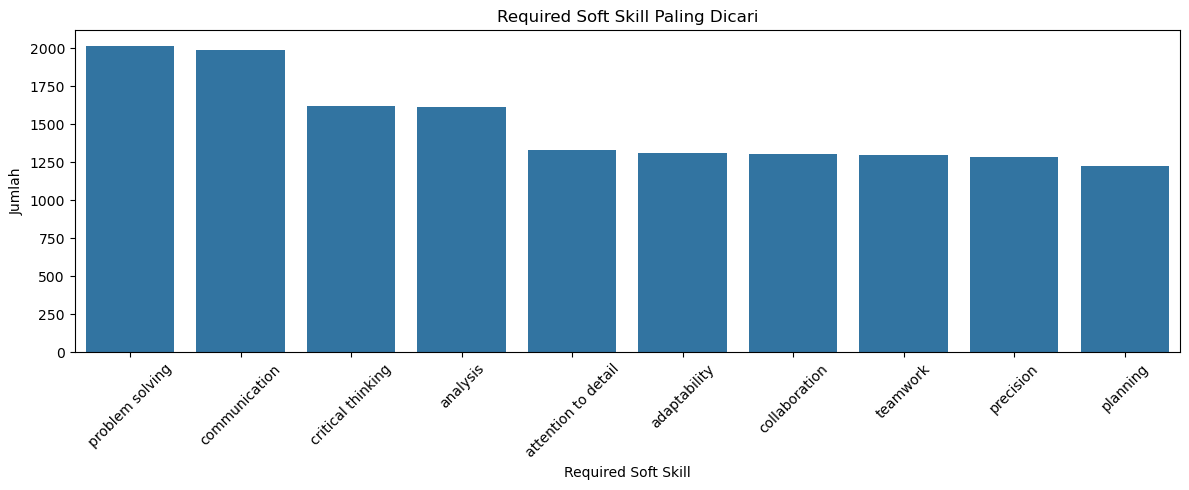

In [18]:
# =========================================================
# PERTANYAAN 4
# Apa required soft skill paling dicari industri?
# =========================================================

required_soft_counter = Counter()

for skills in df['required_soft_skills']:
    required_soft_counter.update(split_skills(skills))

top_required_soft = pd.DataFrame(
    required_soft_counter.most_common(10),
    columns=['Required Soft Skill', 'Jumlah']
)

print("\n===================================")
print("TOP REQUIRED SOFT SKILL")
print("===================================")
print(top_required_soft)

plt.figure(figsize=(12,5))

sns.barplot(
    data=top_required_soft,
    x='Required Soft Skill',
    y='Jumlah'
)

plt.title("Required Soft Skill Paling Dicari")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





TINGKAT KEBUTUHAN SKILL
category
engineering                5.723180
creative_design            5.637577
technology                 5.572782
economy                    5.480636
law_and_public_services    5.462336
Name: total_required_skills, dtype: float64


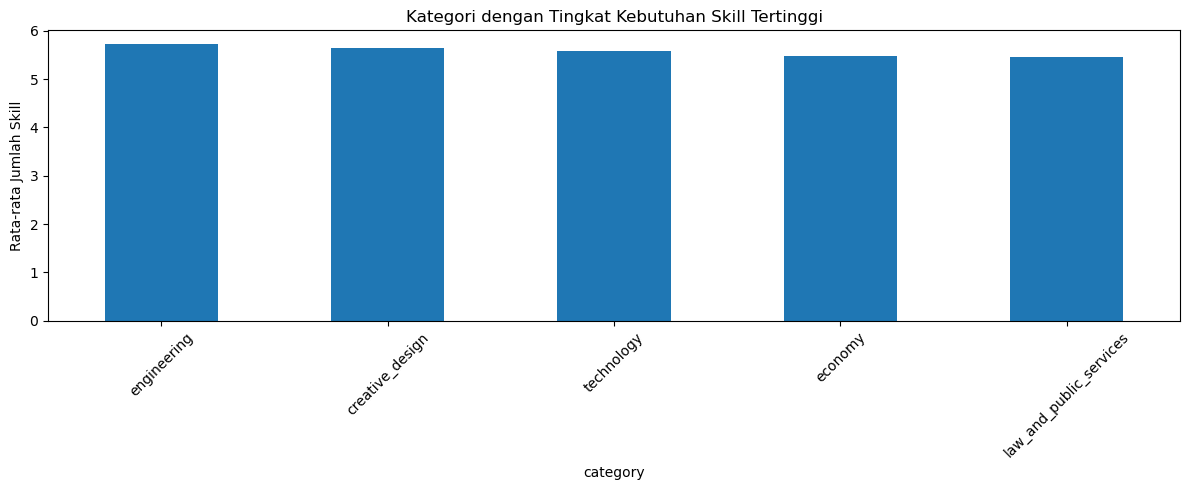

In [19]:
# =========================================================
# PERTANYAAN 5
# Kategori pekerjaan apa yang memiliki tingkat kebutuhan skill tertinggi?
# =========================================================

df['total_required_skills'] = (
    df['required_hard_skills_user'].apply(count_skills) +
    df['required_soft_skills'].apply(count_skills)
)

category_skill_need = (
    df.groupby('category')['total_required_skills']
    .mean()
    .sort_values(ascending=False)
)

print("\n===================================")
print("TINGKAT KEBUTUHAN SKILL")
print("===================================")
print(category_skill_need)

plt.figure(figsize=(12,5))

category_skill_need.plot(
    kind='bar'
)

plt.title("Kategori dengan Tingkat Kebutuhan Skill Tertinggi")
plt.ylabel("Rata-rata Jumlah Skill")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





PERBEDAAN SKILL REQUIREMENT
category
creative_design            5.637577
economy                    5.480636
engineering                5.723180
law_and_public_services    5.462336
technology                 5.572782
Name: total_required_skills, dtype: float64


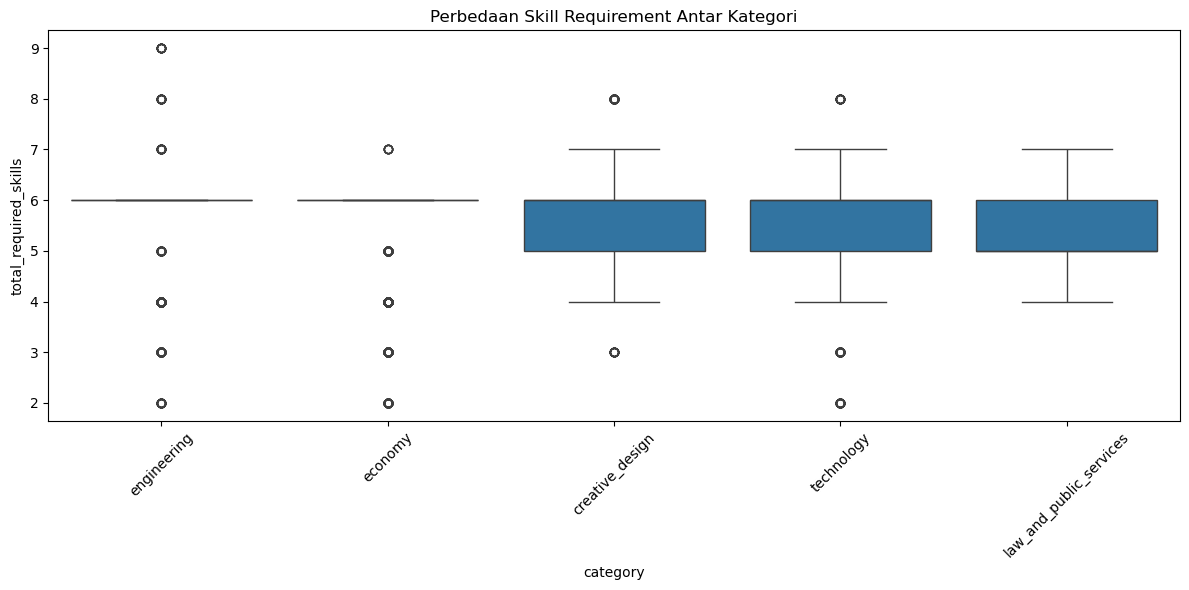

In [20]:
# =========================================================
# PERTANYAAN 6
# Apakah terdapat perbedaan skill requirement antar kategori pekerjaan?
# =========================================================

print("\n===================================")
print("PERBEDAAN SKILL REQUIREMENT")
print("===================================")

skill_requirement = (
    df.groupby('category')['total_required_skills']
    .mean()
)

print(skill_requirement)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='category',
    y='total_required_skills'
)

plt.title("Perbedaan Skill Requirement Antar Kategori")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





TOP SKILL GAP
               Skill Gap  Jumlah
0         graphic design     301
1   adobe creative suite     297
2       video production     216
3                  figma     177
4              animation     164
5       policy knowledge     132
6         legal research     125
7               lighting     123
8  regulatory compliance     114
9              ui design     110


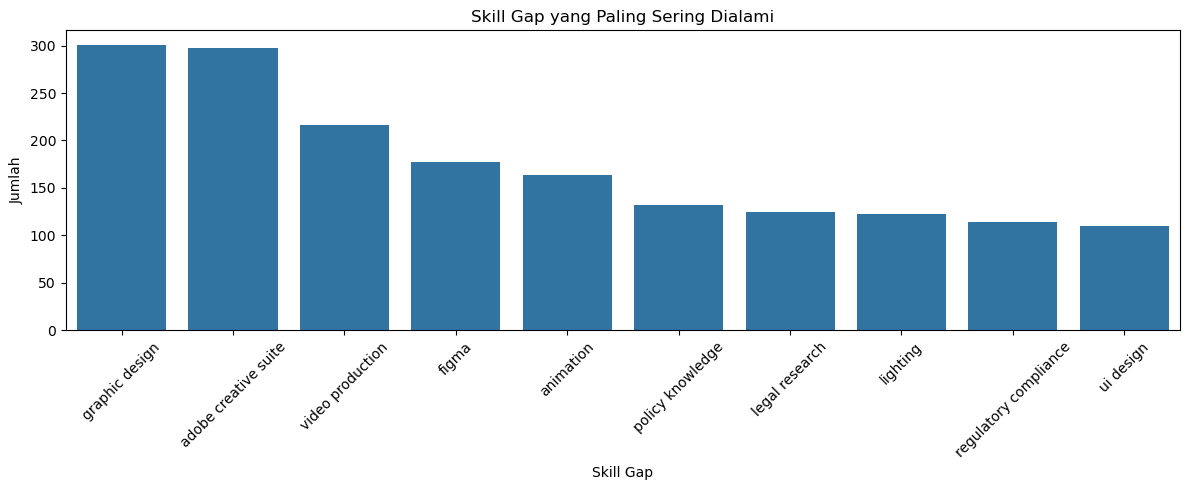

In [21]:
# =========================================================
# PERTANYAAN 7
# Skill gap apa yang paling sering dialami pengguna?
# =========================================================

skill_gap_counter = Counter()

for _, row in df.iterrows():

    user_skills = set(
        split_skills(row['hard_skills_user'])
    )

    required_skills = set(
        split_skills(row['required_hard_skills_user'])
    )

    gap = required_skills - user_skills

    skill_gap_counter.update(gap)

top_skill_gap = pd.DataFrame(
    skill_gap_counter.most_common(10),
    columns=['Skill Gap', 'Jumlah']
)

print("\n===================================")
print("TOP SKILL GAP")
print("===================================")
print(top_skill_gap)

plt.figure(figsize=(12,5))

sns.barplot(
    data=top_skill_gap,
    x='Skill Gap',
    y='Jumlah'
)

plt.title("Skill Gap yang Paling Sering Dialami")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





DISTRIBUSI MATCH SCORE
count    9888.000000
mean        0.722093
std         0.172481
min         0.320000
25%         0.600000
50%         0.730000
75%         0.870000
max         1.000000
Name: match_score, dtype: float64


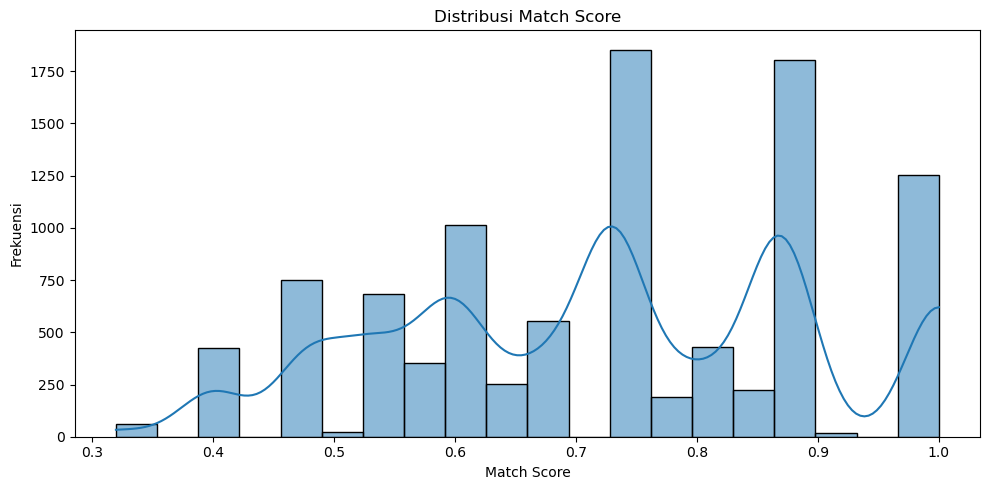


KORELASI SKILL DAN MATCH SCORE
Nilai Korelasi: 0.24046317091654712


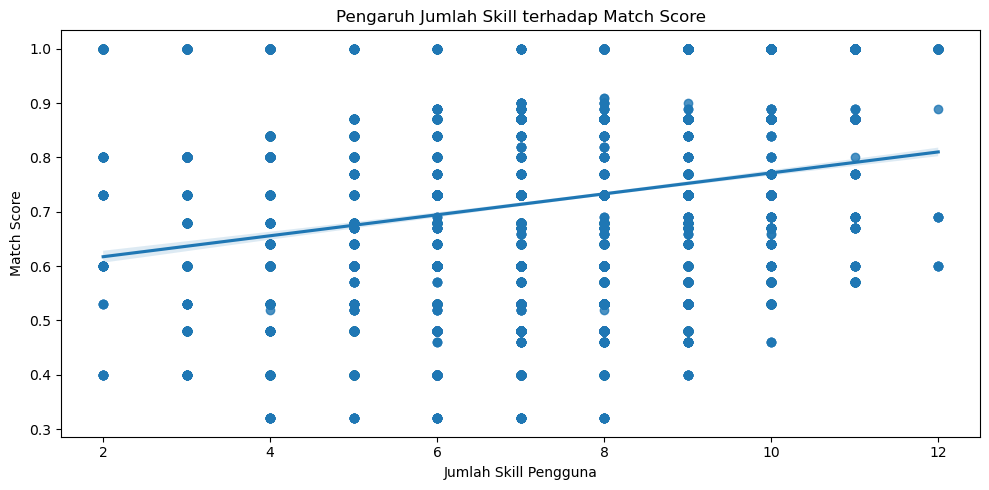


RATA-RATA MATCH SCORE
category
creative_design            0.579774
law_and_public_services    0.586108
technology                 0.796615
economy                    0.800660
engineering                0.826806
Name: match_score, dtype: float64

Kategori dengan Match Score Tertinggi:
engineering = 0.8268055555555555

Kategori dengan Match Score Terendah:
creative_design = 0.5797741273100616


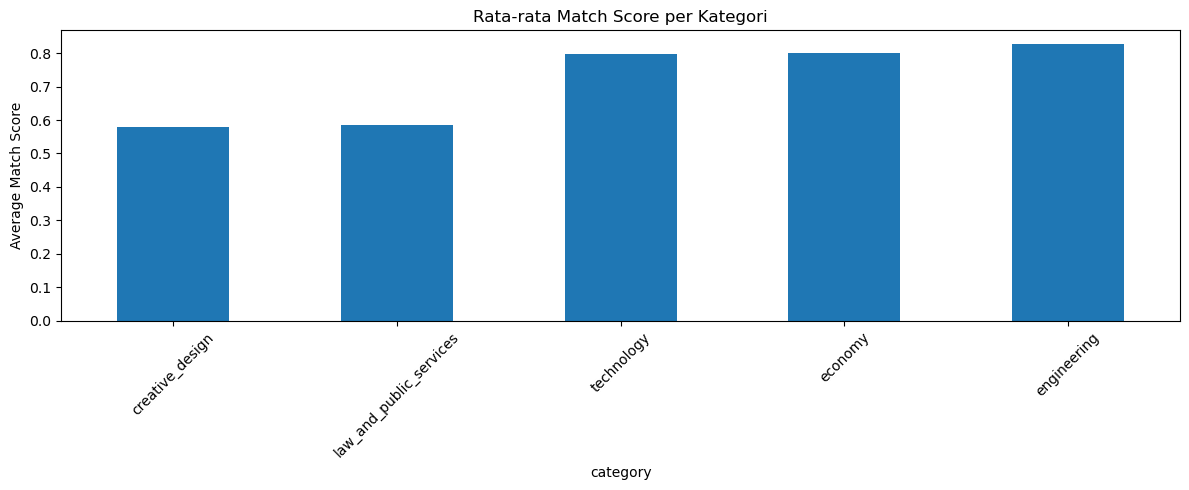

In [22]:
# =========================================================
# PERTANYAAN 8
# Bagaimana distribusi skor kecocokan (match score)?
# =========================================================

print("\n===================================")
print("DISTRIBUSI MATCH SCORE")
print("===================================")

print(df['match_score'].describe())

plt.figure(figsize=(10,5))

sns.histplot(
    df['match_score'],
    bins=20,
    kde=True
)

plt.title("Distribusi Match Score")
plt.xlabel("Match Score")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()


# =========================================================
# PERTANYAAN 9
# Apakah jumlah skill memengaruhi tingkat kecocokan karier?
# =========================================================

df['total_user_skills'] = (
    df['hard_skills_user'].apply(count_skills) +
    df['soft_skills_user'].apply(count_skills)
)

correlation = df['total_user_skills'].corr(
    df['match_score']
)

print("\n===================================")
print("KORELASI SKILL DAN MATCH SCORE")
print("===================================")

print("Nilai Korelasi:", correlation)

plt.figure(figsize=(10,5))

sns.regplot(
    data=df,
    x='total_user_skills',
    y='match_score'
)

plt.title("Pengaruh Jumlah Skill terhadap Match Score")
plt.xlabel("Jumlah Skill Pengguna")
plt.ylabel("Match Score")
plt.tight_layout()
plt.show()


# =========================================================
# PERTANYAAN 10
# Kategori pekerjaan mana yang memiliki rata-rata
# match score tertinggi dan terendah?
# =========================================================

avg_match_score = (
    df.groupby('category')['match_score']
    .mean()
    .sort_values()
)

print("\n===================================")
print("RATA-RATA MATCH SCORE")
print("===================================")

print(avg_match_score)

print("\nKategori dengan Match Score Tertinggi:")
print(avg_match_score.idxmax(), "=", avg_match_score.max())

print("\nKategori dengan Match Score Terendah:")
print(avg_match_score.idxmin(), "=", avg_match_score.min())

plt.figure(figsize=(12,5))

avg_match_score.plot(
    kind='bar'
)

plt.title("Rata-rata Match Score per Kategori")
plt.ylabel("Average Match Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()